In [1]:
from torch.utils.data import DataLoader

import os, time, datetime

import sys
sys.path.append('../../py_scripts')

from SPAC_Dataset import dataset 
from models import *

In [2]:
# CuDNN optimisation
torch.backends.cudnn.benchmark = True

main_dir = "/home/amergez/SPA-C/"
data_dir = os.path.join(main_dir, "datasets_v2", "CHM13.DS", "CHM13.DS_5K10S_Q0.hdf5")

weights = "/home/amergez/SPA-C/models/FF.105Logits/FF.105Logits.Classifier.E02.pth"


print("--- Directories ---")
print("Main :", main_dir)
print("Data :", data_dir)

# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

--- Directories ---
Main : /home/amergez/SPA-C/
Data : /home/amergez/SPA-C/datasets_v2/CHM13.DS/CHM13.DS_5K10S_Q0.hdf5
Using cuda device


In [3]:
model = SPAC(
    device=device,
    name="SPA-C",
    latent_width=64,
    input_shape=(1, 20, 20)
)

model.load_weights(weights)

Weights loaded !


# Errors

## HG002.H1 (lowcomplexity)

In [4]:
HIntra = dataset(
    "/home/amergez/SPA-C/datasets_v2/HG002.H1/SPA-C/HG002.H1.NS.Q0.Intra_5k10s.hdf5",
    bin_size=5000,
    image_size=10,
    skip_check=True
)
HIntra.minmax(max_val=47.0)
HIntra.summary()

HIntra_dl = DataLoader(HIntra.get_as_torch(), batch_size=256, shuffle=False, num_workers=12, pin_memory=True)

DLScaff dataset v5.7

Loading /home/amergez/SPA-C/datasets_v2/HG002.H1/SPA-C/HG002.H1.NS.Q0.Intra_5k10s.hdf5 ...
Done ! (6.505s)

Dataset metadata :
	Cool2IntraM_FullMat.creation_date: 01/27/2026-23:27:42
	Cool2IntraM_FullMat.filter: None
	Cool2IntraM_FullMat.version: 1.8.1
	data.type: Intra.FullMat
	dataset: HG002.H1.JHE

'HG002.H1.JHE' dataset summary - BS:5000 IS:10

	The dataset has been normed.
	Whole dataset :
		x - (1219712, 20, 20)
		y - (1219712,)
		names - (1219712,)
		groups - (1219712,)
		100.0% of the samples are True


In [5]:
import json

ds_name = "H1"
oc_probs, _ = model.predict(
    HIntra_dl,
    savedir="HG002.H1.scores.json",
    names=HIntra.dataset["names"]
)

with open("HG002.H1.scores.json", "r") as handle:
    probs_H1 = json.load(handle)

Predicting on test: 100%|███████████████████████████████████████████████████████████████████████████████████████████| 4765/4765 [00:22<00:00, 210.22batch/s]


In [20]:
import re

# Refining predictions
intra_probs_H1 = {}

def start_or_end(pos):
    if pos == 0: return "Start"
    return "End"

for key, value in probs_H1.items():
    # Decomposing the key

    try:
        chrom_name, bin_number, corner_id = key.rsplit("_", 2)
        bin_number = int(bin_number)
    except Exception as e:
        chrom_name = key
        bin_number = 10
        corner_id = "C2"
    
    # Adding chromosome to intra_probs_H1 if not already
    if not chrom_name in intra_probs_H1.keys():
        intra_probs_H1[chrom_name] = {}

    # Adding bin_number if not already
    if not bin_number in intra_probs_H1[chrom_name].keys():
        intra_probs_H1[chrom_name][bin_number] = {"C2": None, "C3": None}

    # Adding the value
    intra_probs_H1[chrom_name][bin_number][corner_id] = value

## HC2A

In [7]:
HC2A = dataset(
    "/home/amergez/SPA-C/datasets_v2/HG002.C2A/SPA-C_ds/HG002.C2A.IntraFM.5K10S_Q0.ThresEst.hdf5",
    bin_size=5000,
    image_size=10,
    skip_check=True
)
HC2A.minmax(max_val=47.0)
HC2A.summary()

HC2A_dl = DataLoader(HC2A.get_as_torch(), batch_size=256, shuffle=False, num_workers=12, pin_memory=True)

DLScaff dataset v5.7

Loading /home/amergez/DLScaff/datasets_v2/HG002.C2A/SPA-C_ds/HG002.C2A.IntraFM.5K10S_Q0.ThresEst.hdf5 ...
Done ! (2.893s)

Dataset metadata :
	Cool2IntraM_FullMat.creation_date: 11/17/2025-14:59:52
	Cool2IntraM_FullMat.filter: None
	Cool2IntraM_FullMat.version: 1.7.0
	data.type: Intra.FullMat
	dataset: HG002.C2A.JHE

'HG002.C2A.JHE' dataset summary - BS:5000 IS:10

	The dataset has been normed.
	Whole dataset :
		x - (609600, 20, 20)
		y - (609600,)
		names - (609600,)
		groups - (609600,)
		65.0% of the samples are True


In [8]:
import json

ds_name = "HC2A"
oc_probs, _ = model.predict(
    HC2A_dl,
    savedir="HC2A_scores.json",
    names=HC2A.dataset["names"]
)

with open("HC2A_scores.json", "r") as handle:
    probs_HC2A = json.load(handle)

Predicting on test: 100%|███████████████████████████████████████████████████████████████████████████████████████████| 2382/2382 [00:11<00:00, 211.19batch/s]


In [9]:
import re

# Refining predictions
intra_probs_HC2A = {}

def start_or_end(pos):
    if pos == 0: return "Start"
    return "End"

for key, value in probs_HC2A.items():
    # Decomposing the key

    try:
        chrom_name, bin_number, corner_id = key.rsplit("_", 2)
        bin_number = int(bin_number)
    except Exception as e:
        chrom_name = key
        bin_number = 10
        corner_id = "C2"
    
    # Adding chromosome to intra_probs_HC2A if not already
    if not chrom_name in intra_probs_HC2A.keys():
        intra_probs_HC2A[chrom_name] = {}

    # Adding bin_number if not already
    if not bin_number in intra_probs_HC2A[chrom_name].keys():
        intra_probs_HC2A[chrom_name][bin_number] = {"C2": None, "C3": None}

    # Adding the value
    intra_probs_HC2A[chrom_name][bin_number][corner_id] = value

## HC2B

In [11]:
HC2B = dataset(
    "/home/amergez/SPA-C/datasets_v2/HG002.C2B/SPA-C_ds/HG002.C2B.IntraFM.5K10S_Q0.ThresEst.hdf5",
    bin_size=5000,
    image_size=10,
    skip_check=True
)
HC2B.minmax(max_val=47.0)
HC2B.summary()

HC2B_dl = DataLoader(HC2B.get_as_torch(), batch_size=256, shuffle=False, num_workers=12, pin_memory=True)

DLScaff dataset v5.7

Loading /home/amergez/SPA-C/datasets_v2/HG002.C2B/SPA-C_ds/HG002.C2B.IntraFM.5K10S_Q0.ThresEst.hdf5 ...
Done ! (2.987s)

Dataset metadata :
	Cool2IntraM_FullMat.creation_date: 11/17/2025-15:06:01
	Cool2IntraM_FullMat.filter: None
	Cool2IntraM_FullMat.version: 1.7.0
	data.type: Intra.FullMat
	dataset: HG002.C2B.JHE

'HG002.C2B.JHE' dataset summary - BS:5000 IS:10

	The dataset has been normed.
	Whole dataset :
		x - (606640, 20, 20)
		y - (606640,)
		names - (606640,)
		groups - (606640,)
		65.0% of the samples are True


In [12]:
import json

ds_name = "HC2B"
oc_probs, _ = model.predict(
    HC2B_dl,
    savedir="HC2B_scores.json",
    names=HC2B.dataset["names"]
)

with open("HC2B_scores.json", "r") as handle:
    probs_HC2B = json.load(handle)

Predicting on test: 100%|███████████████████████████████████████████████████████████████████████████████████████████| 2370/2370 [00:11<00:00, 203.62batch/s]


In [13]:
import re

# Refining predictions
intra_probs_HC2B = {}

def start_or_end(pos):
    if pos == 0: return "Start"
    return "End"

for key, value in probs_HC2B.items():
    # Decomposing the key

    try:
        chrom_name, bin_number, corner_id = key.rsplit("_", 2)
        bin_number = int(bin_number)
    except Exception as e:
        chrom_name = key
        bin_number = 10
        corner_id = "C2"
    
    # Adding chromosome to intra_probs_HC2B if not already
    if not chrom_name in intra_probs_HC2B.keys():
        intra_probs_HC2B[chrom_name] = {}

    # Adding bin_number if not already
    if not bin_number in intra_probs_HC2B[chrom_name].keys():
        intra_probs_HC2B[chrom_name][bin_number] = {"C2": None, "C3": None}

    # Adding the value
    intra_probs_HC2B[chrom_name][bin_number][corner_id] = value

## HC2C

In [14]:
HC2C = dataset(
    "/home/amergez/SPA-C/datasets_v2/HG002.C2C/SPA-C_ds/HG002.C2C.IntraFM.5K10S_Q0.ThresEst.hdf5",
    bin_size=5000,
    image_size=10,
    skip_check=True
)
HC2C.minmax(max_val=47.0)
HC2C.summary()

HC2C_dl = DataLoader(HC2C.get_as_torch(), batch_size=256, shuffle=False, num_workers=12, pin_memory=True)

DLScaff dataset v5.7

Loading /home/amergez/SPA-C/datasets_v2/HG002.C2C/SPA-C_ds/HG002.C2C.IntraFM.5K10S_Q0.ThresEst.hdf5 ...
Done ! (2.765s)

Dataset metadata :
	Cool2IntraM_FullMat.creation_date: 11/17/2025-15:10:58
	Cool2IntraM_FullMat.filter: None
	Cool2IntraM_FullMat.version: 1.7.0
	data.type: Intra.FullMat
	dataset: HG002.C2C.JHE

'HG002.C2C.JHE' dataset summary - BS:5000 IS:10

	The dataset has been normed.
	Whole dataset :
		x - (536400, 20, 20)
		y - (536400,)
		names - (536400,)
		groups - (536400,)
		65.0% of the samples are True


In [15]:
import json

ds_name = "HC2C"
oc_probs, _ = model.predict(
    HC2C_dl,
    savedir="HC2C_scores.json",
    names=HC2C.dataset["names"]
)

with open("HC2C_scores.json", "r") as handle:
    probs_HC2C = json.load(handle)

Predicting on test: 100%|███████████████████████████████████████████████████████████████████████████████████████████| 2096/2096 [00:11<00:00, 190.03batch/s]


In [16]:
import re

# Refining predictions
intra_probs_HC2C = {}

def start_or_end(pos):
    if pos == 0: return "Start"
    return "End"

for key, value in probs_HC2C.items():
    # Decomposing the key

    try:
        chrom_name, bin_number, corner_id = key.rsplit("_", 2)
        bin_number = int(bin_number)
    except Exception as e:
        chrom_name = key
        bin_number = 10
        corner_id = "C2"
    
    # Adding chromosome to intra_probs_HC2C if not already
    if not chrom_name in intra_probs_HC2C.keys():
        intra_probs_HC2C[chrom_name] = {}

    # Adding bin_number if not already
    if not bin_number in intra_probs_HC2C[chrom_name].keys():
        intra_probs_HC2C[chrom_name][bin_number] = {"C2": None, "C3": None}

    # Adding the value
    intra_probs_HC2C[chrom_name][bin_number][corner_id] = value

## Loading full mat

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
import cooler

genome_id = "HG002.H1"

cool = cooler.Cooler(f"/home/amergez/SPA-C/datasets_v2/{genome_id}/aligned/{genome_id}.JHE.mcool::/resolutions/5000")
mat = cool.matrix(balance=False)

def parse_matrices(ctg1, s1, e1, ctg2, s2, e2, o1, o2, cool):
    mat = cool.matrix(balance=False)
    chromsizes = cool.chromsizes.to_dict()

    T1 = (ctg1, int(s1//5000*5000), int(e1//5000*5000))


    if o1 == "F":
        c1 = np.array(mat.fetch(T1, T1))
    else:
        c1 = np.rot90(np.array(mat.fetch(T1, T1)), k=2)

    T2 = (ctg2, int(s2//5000*5000), int(e2//5000*5000))

    if o2 == "F":
        c2 = np.array(mat.fetch(T2, T2))
    else:
        c2 = np.rot90(np.array(mat.fetch(T2, T2)), k=2)

    if o1 == "F" and o2 == "F":
        c1x2 = np.array(mat.fetch(T1, T2))
        c2x1 = np.array(mat.fetch(T2, T1))
    elif o1 == "R" and o2 == "R":
        c1x2 = np.flip(np.array(mat.fetch(T1, T2)), (0,1))
        c2x1 = np.flip(np.array(mat.fetch(T2, T1)), (0,1))
    elif o1 == "F" and o2 == "R":
        c1x2 = np.flip(np.array(mat.fetch(T1, T2)), (1))
        c2x1 = np.flip(np.array(mat.fetch(T2, T1)), (0))
    elif o1 == "R" and o2 == "F":
        c1x2 = np.flip(np.array(mat.fetch(T1, T2)), (0))
        c2x1 = np.flip(np.array(mat.fetch(T2, T1)), (1))

    return c1, c2, c1x2, c2x1

import re

def reconstruct_mat(name, cool):
    if "|" in name:
        ctg1, s1, e1, ctg2, s2, e2 = re.split(r"\||:|-", name)
        s1, e1, s2, e2 = int(s1), int(e1), int(s2), int(e2)
        #print(ctg1, s1, e1, ctg2, s2, e2)
    else:
        ctg1, s1, e1 = re.split(r"\||:|-", name)
        s1, e1 = int(s1), int(e1)
        ctg2, s2, e2 = None, None, None
        #print(ctg1, s1, e1)

    # Orienting
    if s1 <= e1:
        o1, _s1, _e1 = "F", s1, e1
    else:
        o1, _s1, _e1 = "R", e1, s1
        
    if ctg2 is not None:
        # Orienting
        if s2 <= e2:
            o2, _s2, _e2 = "F", s2, e2
        else:
            o2, _s2, _e2 = "R", e2, s2
        
        c1, c2, c1x2, c2x1 = parse_matrices(ctg1, _s1, _e1, ctg2, _s2, _e2, o1, o2, cool)

        _shape = c1.shape[0]+c2.shape[0]
        _bp = c1.shape[0]
        FMAT = np.zeros((_shape, _shape))
        FMAT[:_bp, :_bp] = c1
        FMAT[_bp:, _bp:] = c2
        FMAT[_bp:, :_bp] = c2x1
        FMAT[:_bp, _bp:] = c1x2

    else:
        mat = cool.matrix(balance=False)
        T = (ctg1, int(_s1//5000*5000), int(_e1//5000*5000))
        FMAT = np.array(mat.fetch(T, T))

    return FMAT

## Figure

In [18]:
rng = np.random.default_rng(seed=42)

select_HC2A = str(rng.choice(a=list(intra_probs_HC2A.keys()), size=1)[0])
select_HC2B = str(rng.choice(a=list(intra_probs_HC2B.keys()), size=1)[0])
select_HC2C = str(rng.choice(a=list(intra_probs_HC2C.keys()), size=1)[0])

# Selecting position with low complexity : 
# chr4_MATERNAL
# 33581 | 33596-33599 | 33621
select_H1 = "chr4_MATERNAL:167905000-168105000"

print(select_HC2A, select_HC2B, select_HC2C, select_H1)

chr13_MATERNAL:56000000-56100000|chr21_MATERNAL:37600000-37700000 chrX_MATERNAL:14600000-14700000|chrX_MATERNAL:19300000-19400000 chr8_MATERNAL:124700000-124800000|chr8_MATERNAL:124900000-124800000 chr4_MATERNAL:167905000-168105000


In [21]:
def get_sort_key(pos, ds):
    name = ds.N[pos]
    bin_id = name.rsplit("_",2)[1]
    return int(bin_id)

"""
def reconstruct_mat(chrom, ds):
    # Getting matrices ids
    lower_names = np.char.lower(ds.N)
    maskA = np.char.find(lower_names, np.char.lower(chrom)) != -1
    maskB = np.char.find(lower_names, np.char.lower("C2")) != -1
    mask = maskA & maskB
    ids = np.where(mask)[0]
    
    sorted_ids = sorted(ids, key=lambda x: get_sort_key(x, ds))
    #print(sorted_ids)
    
    # Reconstructing matrix
    side = ds.X[sorted_ids[0]].shape[0] + len(sorted_ids)-1
    whole_mat = np.zeros((side, side))
    #print(whole_mat.shape)

    for i, _id in enumerate(sorted_ids):
        whole_mat[i:i+20, i:i+20] = ds.X[_id]

    return whole_mat
"""

def smoothing_predictions(x, ctg_probs, window=20):
    """
    Smoothing 'algorithm' using np.convolve to compute the rolling average with a size of <smoothing window>.
    If the contig is smaller than the smoothing window, only the mean is computed.
    """

    mean_probs = np.mean([
        [ctg_probs[k]["C2"] for k in x],
        [ctg_probs[k]["C3"] for k in x]
    ], axis=0)

    if len([ctg_probs[k]["C2"] for k in x]) >= 1.5*window:
        smoothed_probs = np.convolve(
            mean_probs,
            np.ones(window) / window,
            mode="same"
        )
    else:
        smoothed_probs = mean_probs

    return mean_probs, smoothed_probs

def reconstruct_predictions(chrom, intra_probs, full_intra = intra_probs_H1):
    """
    Since the model didn't make predictions between [0, 10[ and [31, 40[, we get them from the full_intra. 
    It can be done since the model has a +/- 10 bin vision for any given position, meaning the error pattern won't be visible.
    """
    x = sorted(list(intra_probs[chrom].keys()))
    c2_probs = [intra_probs[chrom][k]["C2"] for k in x]
    c3_probs = [intra_probs[chrom][k]["C3"] for k in x]

    ctg1, s1, e1, ctg2, s2, e2 = re.split(r"\||:|-", chrom)
    s1, e1, s2, e2 = int(s1), int(e1), int(s2), int(e2)
    #print(ctg1, s1, e1, ctg2, s2, e2)

    if s1 <= e1:
        o1, _s1, _e1 = "F", s1, e1
    else:
        o1, _s1, _e1 = "R", e1, s1    
    if s2 <= e2:
        o2, _s2, _e2 = "F", s2, e2
    else:
        o2, _s2, _e2 = "R", e2, s2
    
    _ = list(range(_s1//5000, _e1//5000))
    ctg1_x = _ if o1=="F" else _[::-1]
    #print(s1, e1, ctg1_x)
    ctg1_c2_probs = [full_intra[ctg1][k]["C2"] for k in ctg1_x[:10]]
    ctg1_c3_probs = [full_intra[ctg1][k]["C3"] for k in ctg1_x[:10]]

    _ = list(range((_s2//5000)+1, (_e2//5000)+1))
    ctg2_x = _ if o2=="F" else _[::-1]
    #print(s2, e2, ctg2_x)
    ctg2_c2_probs = [full_intra[ctg2][k]["C2"] for k in ctg2_x[10:]]
    ctg2_c3_probs = [full_intra[ctg2][k]["C3"] for k in ctg2_x[10:]]

    x = list(range(len(ctg1_c2_probs + ctg2_c2_probs + c2_probs))) 
    c2_probs = ctg1_c2_probs + c2_probs + ctg2_c2_probs
    c3_probs = ctg1_c3_probs + c3_probs + ctg2_c3_probs

    return x, c2_probs, c3_probs

In [22]:
import string
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

def get_pred_curves(tuples, names, savedir, cool, threshold=.05):
    fs = 10
    cpal = ["#F94144", "#90BE6D", "#F3722C", "#43AA8B", "#F8961E", "#4D908E", "#F9844A", "#577590", "#F9C74F", "#277DA1"]
    cpal_idx = 0
    plt.rcParams.update({'font.size': fs, 'legend.fontsize':fs, 'figure.labelsize':fs})
    
    fig, axes = plt.subplots(2, len(tuples), figsize=(3*len(tuples),3.7), dpi=600, height_ratios=[0.9, 0.1], sharex=True)#gridspec_kw={"height_ratios":[10, 1]}) #"width_ratios":[], 

    for k, (chrom, ds, intra_probs, ld_range) in enumerate(tuples):
        # Adding matrix
        arr = reconstruct_mat(chrom, cool)
        axes[0, k].matshow(arr, cmap="hot_r")
        #axes[0, k].axis('off')
        axes[0, k].tick_params(
            axis='both',          
            which='both',         
            bottom=False,         
            top=False,            
            left=False,           
            right=False,          
            labelbottom=False,    
            labeltop=False,       
            labelleft=False,      
            labelright=False      
        )
        axes[0, k].annotate(
            list(string.ascii_uppercase)[k],
            xy=(-0.1, 1.1),
            xycoords="axes fraction",
            fontsize=fs,
            fontweight="bold",
            color="black",
            va="top",
            ha="left",
        )
        axes[0, k].set_title(names[k], fontsize=fs)#, fontweight="bold")

        # Adding legend
        if k !=3:
            labels = re.split(r'_|:|\||-', chrom)
            print(labels)
            
            ## Top
            lineT = mlines.Line2D(
                [-1.5],  # X
                [0.51, 0.99],      # Y
                transform=axes[0, k].get_xaxis_transform(),
                color=cpal[cpal_idx],
                linewidth=4,
                alpha=1,
                solid_capstyle='round'
            )
            fig.text(
                -4.5, 0.75,
                f"{labels[0]}:{int(labels[3])/1000000:.1f}-{int(labels[2])/1000000:.1f}",
                transform=axes[0, k].get_xaxis_transform(), 
                color=cpal[cpal_idx],
                fontsize=fs,
                ha='left',
                va='center',
                rotation="vertical"
            )
            cpal_idx += 1
            ## Bottom
            lineB = mlines.Line2D(
                [-1.5],  # X
                [0.01, 0.49],      # Y
                transform=axes[0, k].get_xaxis_transform(),
                color=cpal[cpal_idx],
                linewidth=4,
                alpha=1,
                solid_capstyle='round'
            )
            fig.text(
                -4.5, 0.25,
                f"{labels[4]}:{int(labels[7])/1000000:.1f}-{int(labels[6])/1000000:.1f}",
                transform=axes[0, k].get_xaxis_transform(), 
                color=cpal[cpal_idx],
                fontsize=fs,
                ha='left',
                va='center',
                rotation="vertical"
            )
            fig.lines.extend([lineT, lineB])
            cpal_idx += 1
            
        else:
            ## Whole
            labels = re.split(r'_|:|\||-', chrom)
            print(labels)
            
            lineT = mlines.Line2D(
                    [-1.5],  # X
                    [0.01, 0.99],      # Y
                    transform=axes[0, k].get_xaxis_transform(),
                    color=cpal[cpal_idx],
                    linewidth=4,
                    alpha=0.7,
                    solid_capstyle='round'
                )
            fig.lines.extend([lineT])
            fig.text(
                -4.5, 0.5,
                f"{labels[0]}:{int(labels[3])/1000000:.1f}-{int(labels[2])/1000000:.1f}",
                transform=axes[0, k].get_xaxis_transform(), 
                color=cpal[cpal_idx],
                fontsize=fs,
                ha='left',
                va='center',
                rotation="vertical"
            )
            cpal_idx += 1
            
        # Reading predictions
        if "|" in chrom:
            x, c2_probs, c3_probs = reconstruct_predictions(chrom, intra_probs, full_intra = intra_probs_H1)
            #print(x, c2_probs, c3_probs)
        else:
            ctg, start, end = re.split(r":|-", chrom)
            x = list(range(int(start)//5000, int(end)//5000))
            c2_probs = [intra_probs[ctg][k]["C2"] for k in x]
            c3_probs = [intra_probs[ctg][k]["C3"] for k in x]
            min_ = min(x)
            x = [k-min_ for k in x]
            #print(x, c2_probs, c3_probs)

        mean_probs = np.mean([
            c2_probs,
            c3_probs
        ], axis=0)
    
        # Adding raw predictions
        axes[1, k].plot(x, mean_probs, color="#0047AB", label="Averaged prediction", alpha=1, linewidth=1.2)
        #axes[1, k].plot(x, c3_probs, label="Reverse", color="orange", alpha=.5, linewidth=1.2)
        axes[1, k].spines["right"].set_visible(False)
        axes[1, k].spines["top"].set_visible(False)
        axes[1, k].set_ylim(-0.2, 1.2)
        axes[1, k].set_yticks([0, 1])
        axes[1, k].set_xticks(np.arange(0, 41, 10))

        # Adding cutting pos
        try:
            _ = np.where(mean_probs < threshold)[0]
            cut_pos = np.mean([x[_[0]], x[_[-1]]])
            axes[1, k].axvline(cut_pos, linewidth=.75, color="black", linestyle=":", label = "Cutting position")
        except Exception as e:
            pass

        if ld_range is not None:
            #axes[0, k].axvline(ld_range[0]+.5-min_, linewidth=.25, color="green", linestyle="-")
            #axes[0, k].axvline(ld_range[1]+.5-min_, linewidth=.25, color="green", linestyle="-")
            axes[0, k].axvspan(ld_range[0]+.5-min_, ld_range[1]+.5-min_, alpha=0.1, color="green", facecolor=None)
        else:
            axes[0, k].plot([17, 22], [22, 17], color='#6a994e', linewidth=2)
        
        if k == 3:
            handles, labels = axes[1, k].get_legend_handles_labels()
            hatch_proxy = mpatches.Patch(
                color='green',
                alpha=0.1,
                label='Longdust predicted region'
            )
            diagonal_line = mlines.Line2D(
                [], [],
                color='#6a994e',
                linewidth=2
            )
            
            handles.extend([hatch_proxy, diagonal_line])
            labels.extend(['Longdust predicted region', "Breakpoint"])
            
            fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.01), frameon=True, facecolor='white', edgecolor='none')        
        
        
    axes[1, 0].set_ylabel("Prediction", fontsize =fs)     
    #plt.tight_layout()

    plt.subplots_adjust(
        top=0.97,
        bottom=0.14,
        hspace=0,
        left=0.03,
        right=0.99
    )
    
    fig.savefig(savedir)
    plt.show()
    plt.close(fig)

['chr13', 'MATERNAL', '56000000', '56100000', 'chr21', 'MATERNAL', '37600000', '37700000']
['chrX', 'MATERNAL', '14600000', '14700000', 'chrX', 'MATERNAL', '19300000', '19400000']
['chr8', 'MATERNAL', '124700000', '124800000', 'chr8', 'MATERNAL', '124900000', '124800000']
['chr4', 'MATERNAL', '167905000', '168105000']


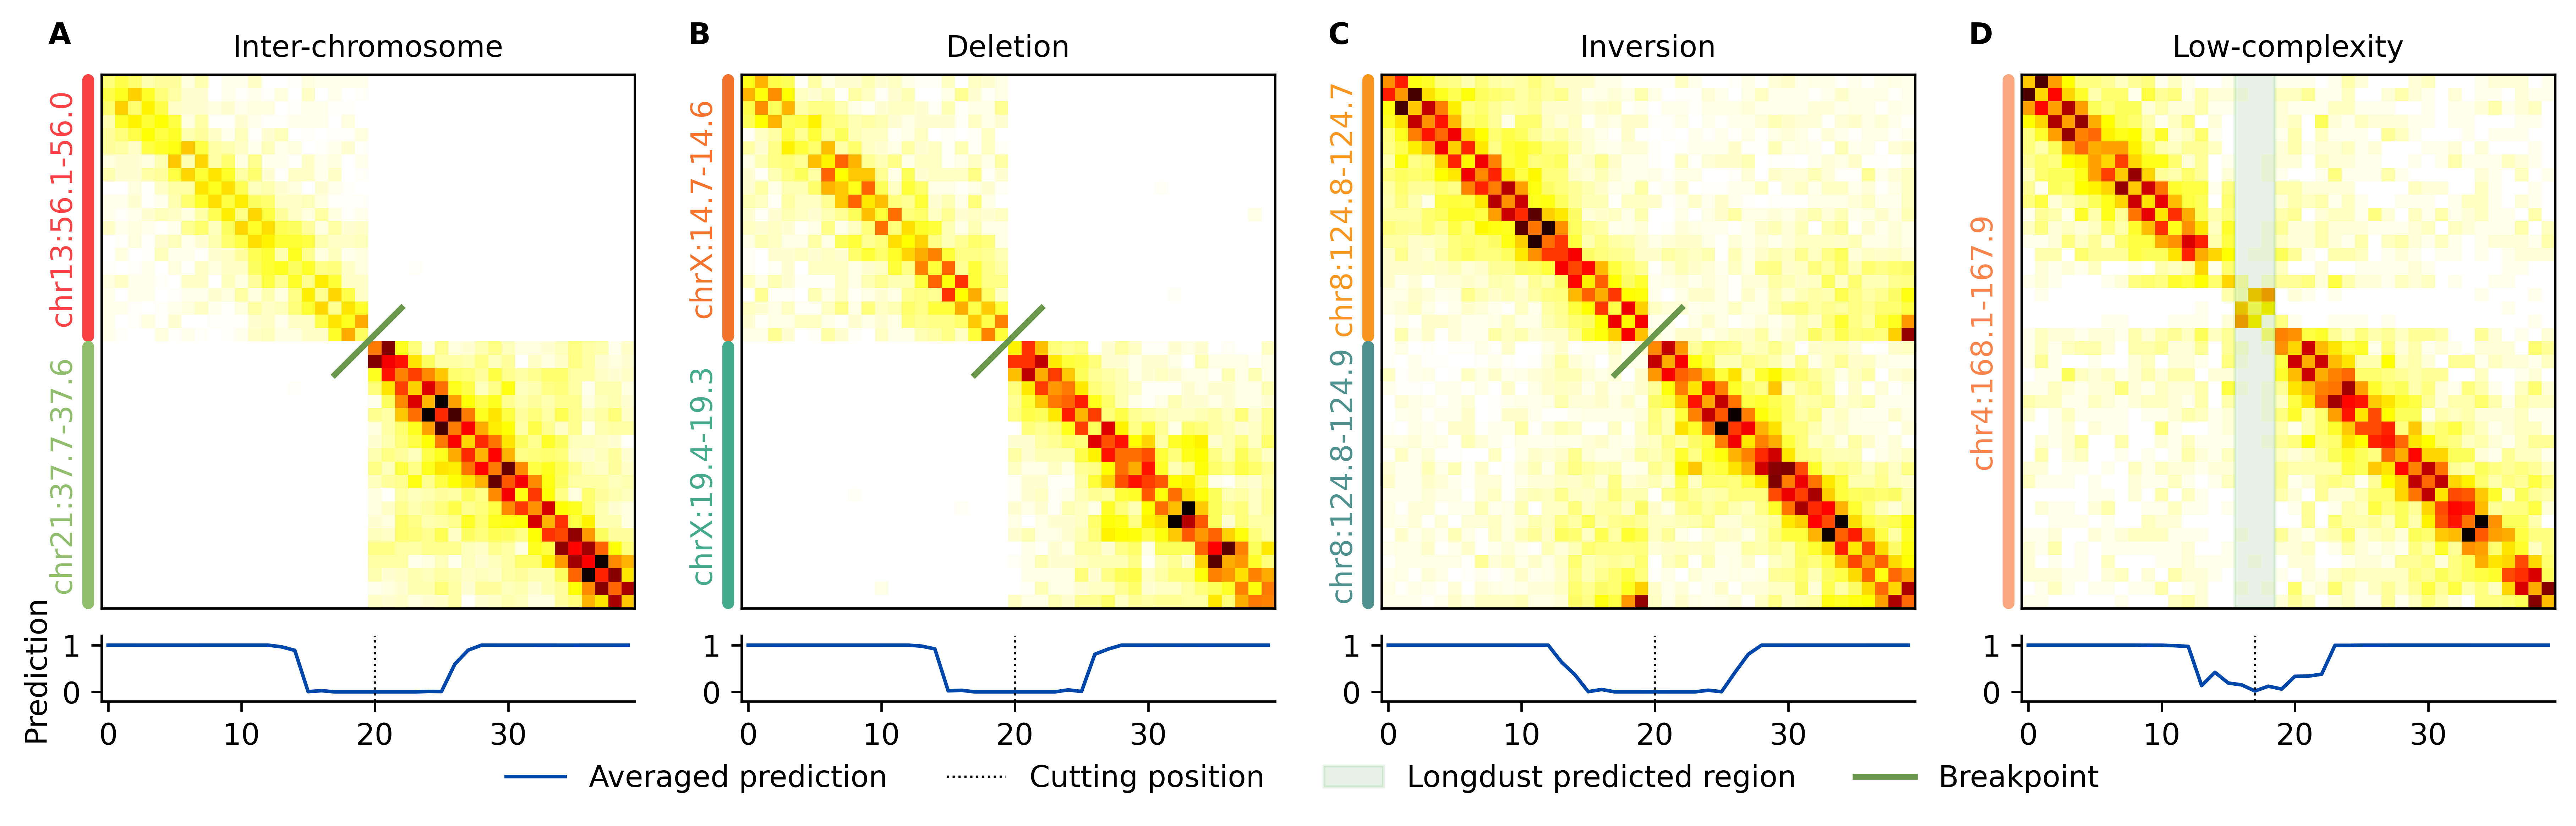

In [23]:
get_pred_curves(
    [
        (select_HC2A, HC2A, intra_probs_HC2A, None), 
        (select_HC2B, HC2B, intra_probs_HC2B, None), 
        (select_HC2C, HC2C, intra_probs_HC2C, None),
        (select_H1, HIntra, intra_probs_H1, [33596, 33599])
        
    ],
    ["Inter-chromosome", "Deletion", "Inversion", "Low-complexity"],
    savedir="PAPER_ERRORSAMPLES.png", 
    threshold=.05,
    cool=cool
)